# Image Classification using CNN Architectures

1. **What is a Convolutional Neural Network (CNN), and how does it differ from
traditional fully connected neural networks in terms of architecture and performance on image data?**
  - ## Convolutional Neural Network (CNN)

    A **Convolutional Neural Network (CNN)** is a deep learning model mainly used for **image processing and classification**. It automatically learns features such as edges, textures, shapes, and objects from images.

    ### CNN vs Fully Connected Neural Network

    | CNN | Fully Connected Neural Network |
    |---|---|
    | Uses convolution and pooling layers | Mainly uses fully connected (Dense) layers |
    | Preserves spatial structure of images | Flattens the image into a 1D vector |
    | Uses fewer parameters through weight sharing | Uses a large number of parameters |
    | Automatically learns local features | Usually requires more computation for images |
    | More efficient and accurate for image tasks | Less suitable for large image data |

    ### Performance on Image Data

    CNNs generally perform better on image data because they can detect **local patterns and spatial relationships** while using fewer parameters.

2. **Discuss the architecture of LeNet-5 and explain how it laid the foundation
for modern deep learning models in computer vision. Include references to its original research paper.**
    ## LeNet-5 Architecture

    **LeNet-5** is an early CNN developed by **Yann LeCun and his collaborators** for handwritten digit recognition.

    ### Architecture

    Input (32×32)
    ↓
    Convolution (6 feature maps)
    ↓
    Average Pooling
    ↓
    Convolution (16 feature maps)
    ↓
    Average Pooling
    ↓
    Fully Connected Layers
    ↓
    Output (10 classes)

    ### Importance

    - Introduced **convolution and pooling** for image recognition.
    - Automatically learned image features.
    - Used **weight sharing**, reducing parameters.
    - Became a foundation for modern CNNs such as **AlexNet, VGG, and ResNet**.

    ### Original Research Paper

    Y. LeCun, L. Bottou, Y. Bengio, and P. Haffner,  
    **"Gradient-Based Learning Applied to Document Recognition," IEEE, 1998.**

3. **Compare and contrast AlexNet and VGGNet in terms of design principles,
number of parameters, and performance. Highlight key innovations and limitations of each.**
    ## AlexNet vs VGGNet

    | Feature | AlexNet | VGGNet |
    |---|---|---|
    | Design | Deeper than earlier CNNs | Uses many small 3×3 filters |
    | Parameters | About 60 million | About 138 million (VGG-16) |
    | Performance | Major improvement in ImageNet classification | Higher accuracy than AlexNet |
    | Key Innovation | ReLU, Dropout, GPU training, data augmentation | Deep architecture with small 3×3 filters |
    | Limitation | Large filters and high computation | Very large number of parameters and high memory usage |

    ### Conclusion

    **AlexNet** introduced important techniques that made deep CNNs practical, while **VGGNet** showed that increasing depth with small filters can significantly improve image recognition performance.

4. **What is transfer learning in the context of image classification? Explain
how it helps in reducing computational costs and improving model performance with limited data.**
    ## Transfer Learning

    **Transfer Learning** is a technique where a pre-trained model is reused for a new image classification task.

    ### How It Helps

    - **Reduces computational cost:** Instead of training a CNN from scratch, we use a model already trained on a large dataset.
    - **Works with limited data:** Pre-trained models have already learned useful features such as edges, textures, and shapes.
    - **Improves performance:** Fine-tuning the pre-trained model can give better accuracy with a small dataset.
    - **Saves training time:** Fewer training epochs and less computational power are required.

    ### Example

    A pre-trained **VGG16, ResNet, or MobileNet** model can be used for a new classification task by replacing its final layer with a new classification layer.

5. **Describe the role of residual connections in ResNet architecture. How do
they address the vanishing gradient problem in deep CNNs?**
    ## Residual Connections in ResNet

    **Residual connections** are shortcut connections that skip one or more layers and directly pass the input to a deeper layer.

    ### Working

    Instead of learning the complete mapping `H(x)`, the network learns a residual function `F(x)`:

    `Output = F(x) + x`

    ### How They Solve Vanishing Gradient

    - Shortcut connections provide a **direct path for gradients** during backpropagation.
    - This helps gradients flow through very deep networks.
    - They reduce the **vanishing gradient problem**.
    - They allow ResNet to train much deeper CNNs effectively.



6. **Implement the LeNet-5 architectures using Tensorflow or PyTorch to
classify the MNIST dataset. Report the accuracy and training time.**

In [2]:
import tensorflow as tf
import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Convert uint8 to float32
x_train = x_train.astype("float32")
x_test = x_test.astype("float32")

# Resize images from 28x28 to 32x32
x_train = tf.pad(x_train, [[0, 0], [2, 2], [2, 2]])
x_test = tf.pad(x_test, [[0, 0], [2, 2], [2, 2]])

# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

# Add channel dimension
x_train = tf.expand_dims(x_train, -1)
x_test = tf.expand_dims(x_test, -1)

# Build LeNet-5 model
model = Sequential([
    Conv2D(6, (5, 5), activation="tanh", input_shape=(32, 32, 1)),
    AveragePooling2D(pool_size=(2, 2)),

    Conv2D(16, (5, 5), activation="tanh"),
    AveragePooling2D(pool_size=(2, 2)),

    Conv2D(120, (5, 5), activation="tanh"),

    Flatten(),
    Dense(84, activation="tanh"),
    Dense(10, activation="softmax")
])

# Compile model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Start timer
start_time = time.time()

# Train model
model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    verbose=1
)

# Calculate training time
training_time = time.time() - start_time

# Evaluate model
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("\nTest Accuracy:", round(test_accuracy * 100, 2), "%")
print("Training Time:", round(training_time, 2), "seconds")

# Model architecture
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 37s 36ms/step - accuracy: 0.9208 - loss: 0.2708
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 36s 38ms/step - accuracy: 0.9703 - loss: 0.0995
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 36s 39ms/step - accuracy: 0.9807 - loss: 0.0637
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 34s 36ms/step - accuracy: 0.9852 - loss: 0.0471
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 35s 37ms/step - accuracy: 0.9882 - loss: 0.0372

Test Accuracy: 98.53 %
Training Time: 177.55 seconds


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 1, 1, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,120 (723.13 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 123,414 (482.09 KB)

7. **Use a pre-trained VGG16 model (via transfer learning) on a small custom
dataset (e.g., flowers or animals). Replace the top layers and fine-tune the model. Include your code and result discussion.**

In [ ]:
import tensorflow as tf
import time

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

# Dataset path
dataset_path = "/content/flowers"

# Image preprocessing and augmentation
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# Training data
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

# Validation data
validation_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

# Load pre-trained VGG16
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model layers
base_model.trainable = False

# Replace top layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(train_data.num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train top layers
start_time = time.time()

history = model.fit(
    train_data,
    epochs=5,
    validation_data=validation_data
)

training_time = time.time() - start_time

# Fine-tuning: unfreeze last few VGG16 layers
base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Fine-tune the model
history_fine = model.fit(
    train_data,
    epochs=3,
    validation_data=validation_data
)

print("\nTraining Time:", round(training_time, 2), "seconds")

# Final evaluation
loss, accuracy = model.evaluate(validation_data, verbose=0)

print("Validation Accuracy:", round(accuracy * 100, 2), "%")

8. **Write a program to visualize the filters and feature maps of the first
convolutional layer of AlexNet on an example input image.**

117948/117948 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


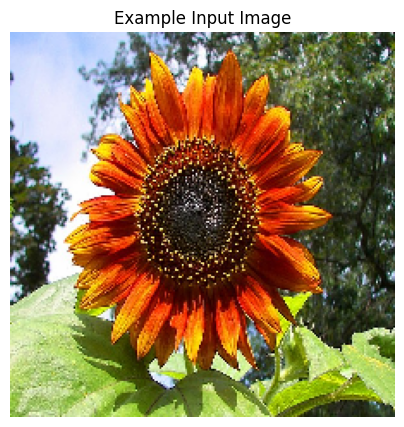

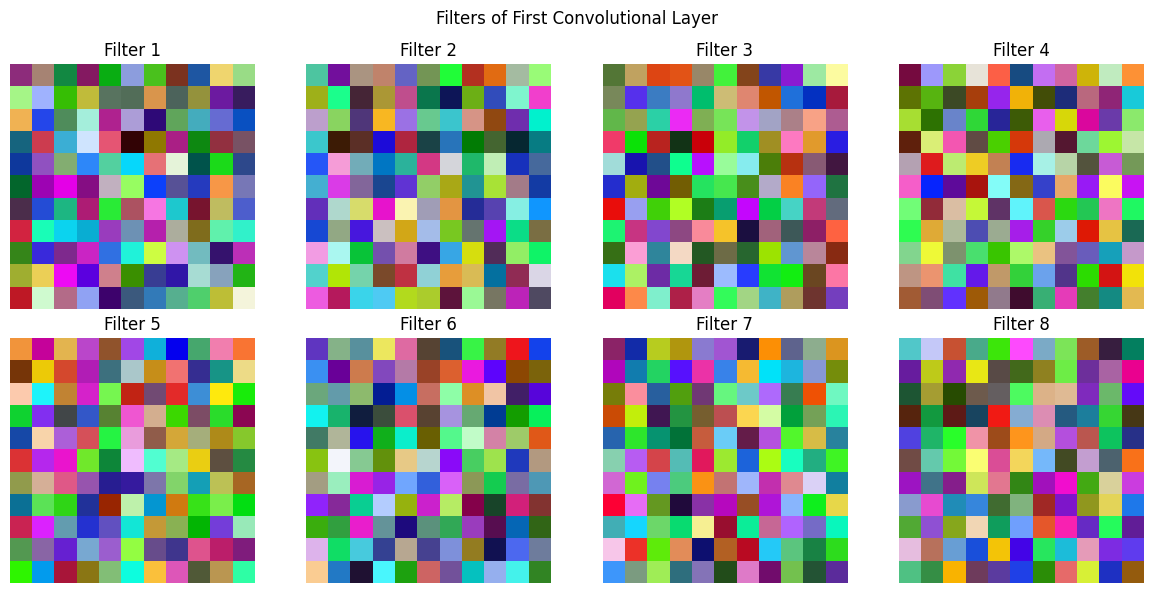

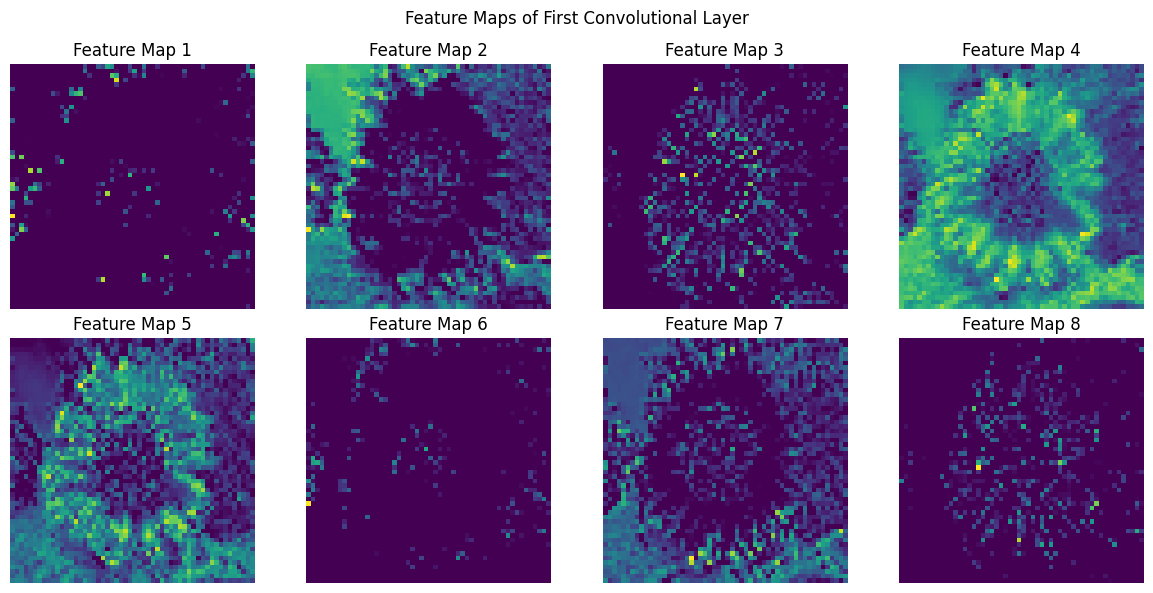

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load example image
image_path = tf.keras.utils.get_file(
    "sunflower.jpg",
    "https://storage.googleapis.com/download.tensorflow.org/example_images/592px-Red_sunflower.jpg"
)

# Load and preprocess image
img = tf.keras.utils.load_img(image_path, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# AlexNet first convolutional layer
conv1 = tf.keras.layers.Conv2D(
    filters=8,
    kernel_size=(11, 11),
    strides=(4, 4),
    activation="relu",
    input_shape=(224, 224, 3)
)

# Generate feature maps
feature_maps = conv1(img_array)

# Display input image
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title("Example Input Image")
plt.axis("off")
plt.show()

# Get filters
filters = conv1.get_weights()[0]

# Display filters
plt.figure(figsize=(12, 6))

for i in range(8):
    filter_img = filters[:, :, :, i]

    filter_img = (
        filter_img - filter_img.min()
    ) / (
        filter_img.max() - filter_img.min() + 1e-8
    )

    plt.subplot(2, 4, i + 1)
    plt.imshow(filter_img)
    plt.title(f"Filter {i + 1}")
    plt.axis("off")

plt.suptitle("Filters of First Convolutional Layer")
plt.tight_layout()
plt.show()

# Display feature maps
plt.figure(figsize=(12, 6))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(feature_maps[0, :, :, i], cmap="viridis")
    plt.title(f"Feature Map {i + 1}")
    plt.axis("off")

plt.suptitle("Feature Maps of First Convolutional Layer")
plt.tight_layout()
plt.show()

9. **Train a GoogLeNet (Inception v1) or its variant using a standard dataset
like CIFAR-10. Plot the training and validation accuracy over epochs and analyze
overfitting or underfitting.**

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, AveragePooling2D
from tensorflow.keras.layers import Concatenate, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize images
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Split training data into training and validation sets
x_val = x_train[-5000:]
y_val = y_train[-5000:]

x_train = x_train[:-5000]
y_train = y_train[:-5000]

# Inception block
def inception_block(x, filters):
    f1, f3, f5, fp = filters

    branch1 = Conv2D(f1, (1, 1), padding="same", activation="relu")(x)

    branch2 = Conv2D(f3, (1, 1), padding="same", activation="relu")(x)
    branch2 = Conv2D(f3, (3, 3), padding="same", activation="relu")(branch2)

    branch3 = Conv2D(f5, (1, 1), padding="same", activation="relu")(x)
    branch3 = Conv2D(f5, (5, 5), padding="same", activation="relu")(branch3)

    branch4 = MaxPooling2D((3, 3), strides=(1, 1), padding="same")(x)
    branch4 = Conv2D(fp, (1, 1), padding="same", activation="relu")(branch4)

    return Concatenate()([branch1, branch2, branch3, branch4])


# Build GoogLeNet-style model
inputs = Input(shape=(32, 32, 3))

x = Conv2D(64, (3, 3), padding="same", activation="relu")(inputs)
x = MaxPooling2D((2, 2))(x)

x = inception_block(x, [32, 32, 16, 16])
x = inception_block(x, [64, 64, 32, 32])

x = MaxPooling2D((2, 2))(x)

x = inception_block(x, [64, 64, 32, 32])
x = inception_block(x, [128, 128, 64, 64])

x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)

outputs = Dense(10, activation="softmax")(x)

model = Model(inputs, outputs)

# Compile model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train model
history = model.fit(
    x_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_data=(x_val, y_val)
)

# Evaluate on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print("\nTest Accuracy:", round(test_accuracy * 100, 2), "%")

# Plot training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

10. **You are working in a healthcare AI startup. Your team is tasked with
developing a system that automatically classifies medical X-ray images into normal, pneumonia, and COVID-19. Due to limited labeled data, what approach would you suggest using among CNN architectures discussed (e.g., transfer learning with ResNet or Inception variants)? Justify your approach and outline a deployment strategy for production use.**

    ## Medical X-ray Classification using Transfer Learning

    For this task, I would recommend **transfer learning with ResNet50** because the labeled medical X-ray dataset is small.

    ### Why ResNet50?

    - ResNet50 is a deep CNN pre-trained on ImageNet.
    - It already learns useful low-level features such as edges, textures, and shapes.
    - Transfer learning reduces training time and the amount of labeled data required.
    - Residual connections help train deep networks and reduce the vanishing-gradient problem.
    - ResNet50 is generally easier to fine-tune and deploy than a very large model.
    - The final classification layer can be replaced with a 3-class softmax layer for:
      - Normal
      - Pneumonia
      - COVID-19

    ### Proposed Architecture

    Input X-ray (224×224)
    ↓
    Pre-trained ResNet50
    ↓
    Global Average Pooling
    ↓
    Dense Layer + Dropout
    ↓
    Softmax Output (3 Classes)

    ### Training Approach

    1. Resize X-ray images to 224×224 and normalize them using the preprocessing required by ResNet50.
    2. Apply data augmentation such as small rotations, zoom, and horizontal shifts.
    3. Initially freeze the ResNet50 base and train only the new classification layers.
    4. Unfreeze the last few ResNet50 layers and fine-tune them using a very small learning rate.
    5. Use categorical cross-entropy loss and Adam optimizer.
    6. Use class weights or balanced sampling if the three classes are imbalanced.
    7. Use early stopping and learning-rate reduction to reduce overfitting.

    ### Evaluation

    Accuracy alone is not sufficient for medical classification. I would evaluate:

    - Precision
    - Recall/Sensitivity
    - Specificity
    - F1-score
    - Confusion Matrix
    - ROC-AUC

    Special attention should be given to **recall/sensitivity**, because missing a pneumonia or COVID-19 case can have serious consequences.

    ### Production Deployment Strategy

    1. Train and validate the ResNet50 model using carefully separated patient-level datasets.
    2. Test it on an independent external dataset from a different hospital or imaging source.
    3. Save the trained model and create a preprocessing pipeline identical to training.
    4. Build an API using FastAPI or Flask.
    5. Deploy the model in a Docker container.
    6. Connect the API to the hospital/clinical application.
    7. The workflow would be:

      X-ray Upload → Preprocessing → ResNet50 → Prediction + Confidence → Clinical Review

    8. Log model predictions and monitor performance, data drift, and failures.
    9. Retrain or fine-tune the model when sufficiently new and validated data becomes available.
    10. Use encryption, access control, audit logging, and appropriate privacy protections for patient data.

    ### Conclusion

    For a small labeled dataset, **ResNet50 with transfer learning and careful fine-tuning** would be my first choice. It provides a strong balance between feature extraction ability, training efficiency, and deployment practicality.

    The system should be treated as a **clinical decision-support tool rather than a replacement for radiologists or physicians**. Before real clinical use, it would require rigorous external validation, safety testing, regulatory review, and continuous monitoring.